# Employee Attrition – EDA Notebook

This notebook performs **exploratory data analysis (EDA)** on the IBM HR Analytics Employee Attrition dataset.
We also Predict whether employees are likely to leave a company using demographic, job satisfaction, and performance data.

We will:
- Load the dataset from `WA_Fn-UseC_-HR-Employee-Attrition.csv`
- Inspect the basic structure and target distribution
- Explore attrition patterns by:
  - **Age band**
  - **Job Role**
  - **Work–Life Balance**

Model training, evaluation, and interpretability (XGBoost, Logistic Regression, Random Forest, feature importance, SHAP) are implemented in the Python script:
`employee_attrition_main.py`.


Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap


Load the Dataset

In [4]:


# Download latest version of the IBM HR Analytics dataset from Kaggle
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("Path to dataset files:", path)

# The CSV we need is inside that folder
csv_path = os.path.join(path, "WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = pd.read_csv(csv_path)
df.head()



100%|██████████| 50.1k/50.1k [00:00<00:00, 17.4MB/s]

Extracting files...
Path to dataset files: /Users/tchandrasekaran/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nAttrition distribution (counts):")
print(df["Attrition"].value_counts())

print("\nAttrition distribution (percentage):")
print((df["Attrition"].value_counts(normalize=True) * 100).round(2))

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel    

## Attrition by Age Band

/var/folders/cn/hndy0c116ylgj1rkvgbrv8380000gn/T/ipykernel_47553/394489462.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeBand')['Attrition']


,AgeBand,Attrition,Rate
1,18–25,Yes,0.357724
3,26–35,Yes,0.191419
5,36–45,Yes,0.091880
7,46–55,Yes,0.115044
9,56+,Yes,0.170213


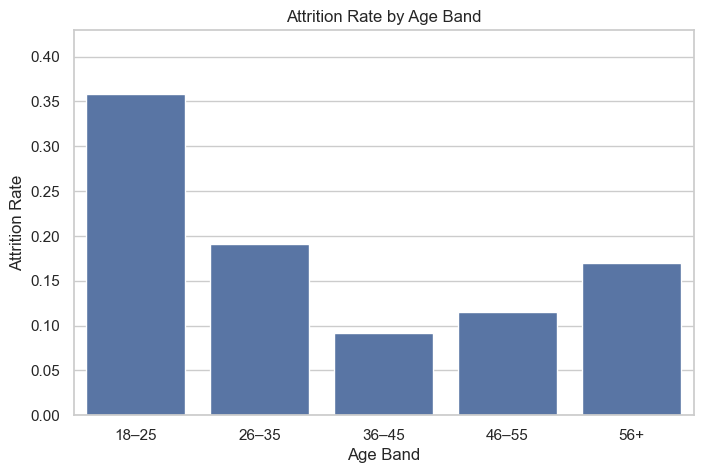

In [6]:
# Create age bands
df['AgeBand'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 70],
    labels=['18–25', '26–35', '36–45', '46–55', '56+']
)

# Compute attrition rate within each age band
attrition_by_age = (
    df.groupby('AgeBand')['Attrition']
      .value_counts(normalize=True)
      .rename('Rate')
      .reset_index()
)

# Filter to 'Yes' (employees who left)
attrition_by_age_yes = attrition_by_age[attrition_by_age['Attrition'] == 'Yes']

display(attrition_by_age_yes.sort_values('AgeBand'))

plt.figure()
sns.barplot(data=attrition_by_age_yes, x='AgeBand', y='Rate')
plt.title("Attrition Rate by Age Band")
plt.ylabel("Attrition Rate")
plt.xlabel("Age Band")
plt.ylim(0, attrition_by_age_yes['Rate'].max() * 1.2)
plt.show()

## Attrition by Job Role

,JobRole,Attrition,Rate
17,Sales Representative,Yes,0.397590
5,Laboratory Technician,Yes,0.239382
3,Human Resources,Yes,0.230769
15,Sales Executive,Yes,0.174847
13,Research Scientist,Yes,0.160959
9,Manufacturing Director,Yes,0.068966
1,Healthcare Representative,Yes,0.068702
7,Manager,Yes,0.049020
11,Research Director,Yes,0.025000


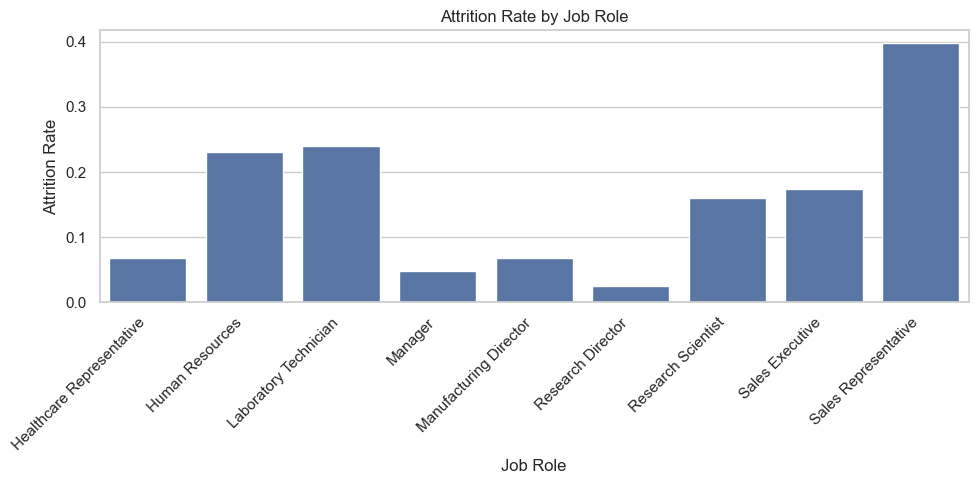

In [7]:
attrition_by_role = (
    df.groupby('JobRole')['Attrition']
      .value_counts(normalize=True)
      .rename('Rate')
      .reset_index()
)

attrition_by_role_yes = attrition_by_role[attrition_by_role['Attrition'] == 'Yes']

display(attrition_by_role_yes.sort_values('Rate', ascending=False))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=attrition_by_role_yes,
    x='JobRole',
    y='Rate'
)
plt.xticks(rotation=45, ha='right')
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate")
plt.xlabel("Job Role")
plt.tight_layout()
plt.show()

## Attrition by Work–Life Balance

,WorkLifeBalance,Attrition,Rate
1,1,Yes,0.312500
3,2,Yes,0.168605
5,3,Yes,0.142217
7,4,Yes,0.176471


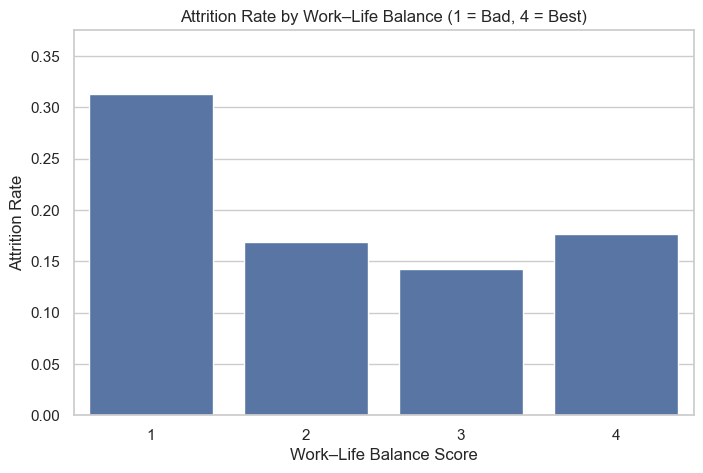

In [8]:
# In this dataset, WorkLifeBalance is usually coded as:
# 1 = Bad, 2 = Good, 3 = Better, 4 = Best

attrition_by_wlb = (
    df.groupby('WorkLifeBalance')['Attrition']
      .value_counts(normalize=True)
      .rename('Rate')
      .reset_index()
)

attrition_by_wlb_yes = attrition_by_wlb[attrition_by_wlb['Attrition'] == 'Yes']

display(attrition_by_wlb_yes.sort_values('WorkLifeBalance'))

plt.figure()
sns.barplot(
    data=attrition_by_wlb_yes,
    x='WorkLifeBalance',
    y='Rate'
)
plt.title("Attrition Rate by Work–Life Balance (1 = Bad, 4 = Best)")
plt.ylabel("Attrition Rate")
plt.xlabel("Work–Life Balance Score")
plt.ylim(0, attrition_by_wlb_yes['Rate'].max() * 1.2)
plt.show()

Preprocessing

In [12]:
# Separate target and features
X = df.drop("Attrition", axis=1)
y = df["Attrition"].apply(lambda x: 1 if x == "Yes" else 0)

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Define transformers
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


Model Training – XGBoost

In [14]:
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", xgb_clf)])
xgb_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Evaluation Metrics

In [15]:
y_pred = xgb_pipeline.predict(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8333
F1-score: 0.4731
ROC-AUC: 0.7681

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.48      0.47      0.47        47

    accuracy                           0.83       294
   macro avg       0.69      0.69      0.69       294
weighted avg       0.83      0.83      0.83       294



Feature Importance (XGBoost)

/var/folders/cn/hndy0c116ylgj1rkvgbrv8380000gn/T/ipykernel_47553/19444661.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


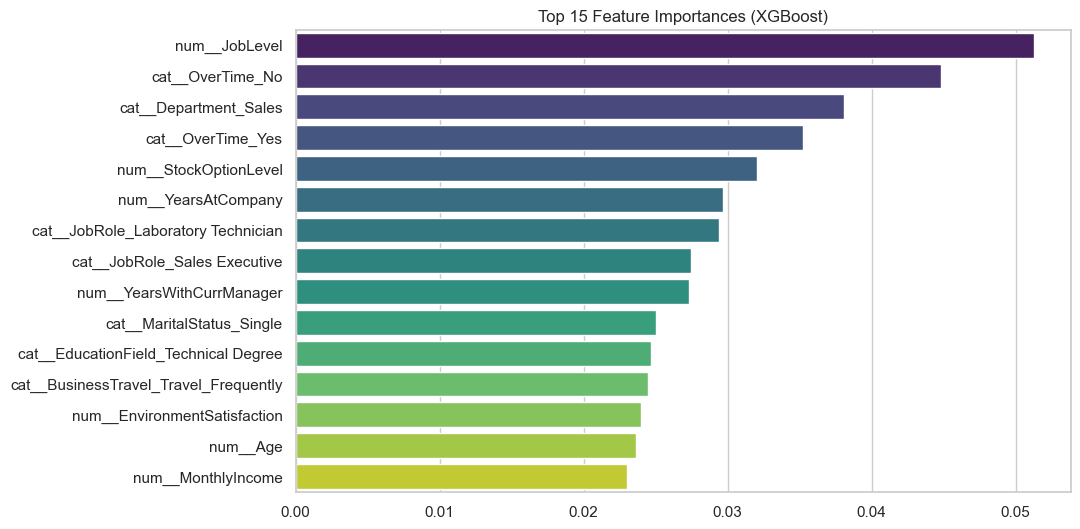

In [16]:
# Extract trained model and feature names
xgb_model = xgb_pipeline.named_steps["model"]
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()


SHAP Summary Plot

/var/folders/cn/hndy0c116ylgj1rkvgbrv8380000gn/T/ipykernel_47553/3039499655.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_sample, feature_names=feature_names)


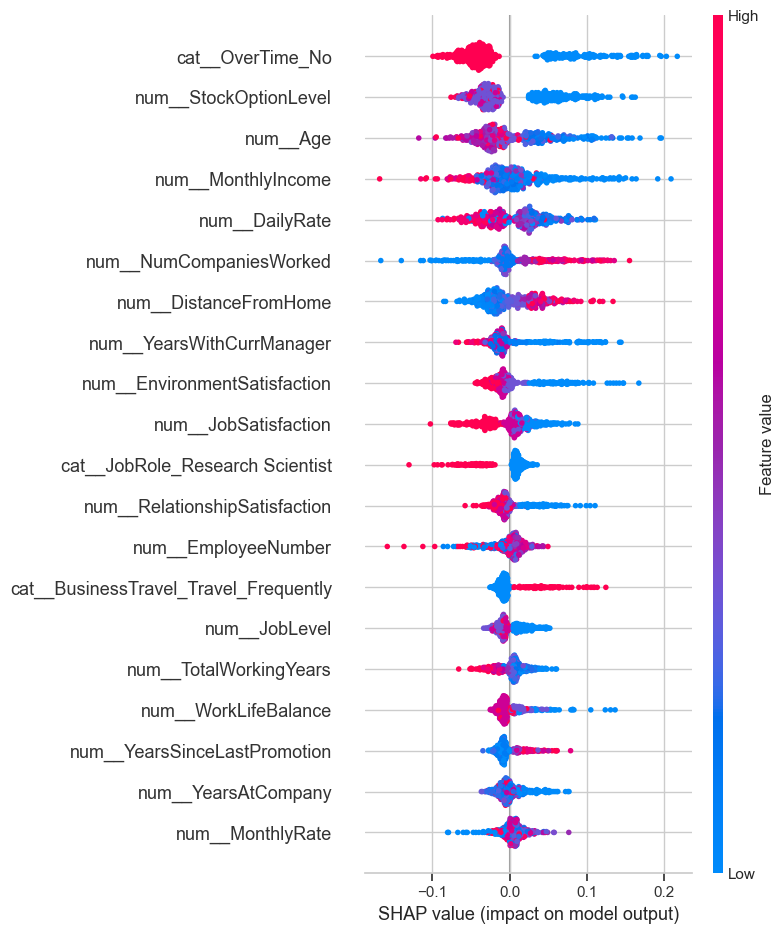

In [17]:
import shap

# 1. Get preprocessor + underlying XGBoost model from the pipeline
preprocessor = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

# 2. Transform the training data
X_train_transformed = preprocessor.transform(X_train)

# 3. For speed, sample up to 500 rows
n_samples = min(500, X_train_transformed.shape[0])
rng = np.random.RandomState(42)
idx = rng.choice(X_train_transformed.shape[0], size=n_samples, replace=False)
X_sample = X_train_transformed[idx]

# 4. Define a callable model: SHAP will call this with transformed features
def model_fn(x):
    # x is already in transformed feature space
    return xgb_model.predict_proba(x)[:, 1]

# 5. Build a generic SHAP Explainer using the callable model + sample as masker
explainer = shap.Explainer(model_fn, X_sample, feature_names=feature_names)

# 6. Compute SHAP values on the sample
shap_values = explainer(X_sample)

# 7. Summary plot
shap.summary_plot(shap_values.values, X_sample, feature_names=feature_names)




Model Comparison (Bonus)

In [18]:
models = {
    "XGBoost": xgb_pipeline,
    "LogisticRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")),
    ]),
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)),
    ]),
}

metrics = []
for name, pipe in models.items():
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    metrics.append((name, acc, f1, roc))
    print(f"{name} -> Acc: {acc:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}")

pd.DataFrame(metrics, columns=["Model", "Accuracy", "F1", "ROC-AUC"])



Training XGBoost...
XGBoost -> Acc: 0.8333, F1: 0.4731, ROC-AUC: 0.7681

Training LogisticRegression...
LogisticRegression -> Acc: 0.7449, F1: 0.4444, ROC-AUC: 0.7978

Training RandomForest...
RandomForest -> Acc: 0.8537, F1: 0.1887, ROC-AUC: 0.7862


,Model,Accuracy,F1,ROC-AUC
0,XGBoost,0.833333,0.473118,0.768111
1,LogisticRegression,0.744898,0.444444,0.797829
2,RandomForest,0.853741,0.188679,0.786243
